# 04c: Customer Segmentation with Agglomerative Hierarchical Clustering

**RetailPulse AI Platform** • *Dedicated Model Training & Evaluation*

### Model Scope:
- Ingest log-transformed, StandardScaler-normalized RFM features.
- Train Agglomerative Hierarchical Clustering.
- Compute full cluster separation statistics:
  - **Silhouette Score**
  - **Calinski-Harabasz Index**
  - **Davies-Bouldin Index**
- Analyze cluster profiles (Mean/Median Recency, Frequency, Monetary) and render 2D PCA cluster visualization.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

model_name = 'Agglomerative Hierarchical Clustering'
rfm_path = os.path.join('..', '..', 'data', 'processed', 'rfm_features.csv')
rfm = pd.read_csv(rfm_path)
X = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Customer RFM records: {len(rfm):,}')

Customer RFM records: 5,878


In [2]:
# Train Agglomerative Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = model.fit_predict(X_scaled)
rfm['Cluster'] = labels

# Compute Model Statistics
valid_mask = labels != -1 if -1 in labels else slice(None)
sil = silhouette_score(X_scaled[valid_mask], labels[valid_mask])
ch = calinski_harabasz_score(X_scaled[valid_mask], labels[valid_mask])
db = davies_bouldin_score(X_scaled[valid_mask], labels[valid_mask])

print('========================================')
print(f'AGGLOMERATIVE HIERARCHICAL CLUSTERING EVALUATION STATISTICS:')
print('========================================')
print(f'Clusters Identified: {len(set(labels[valid_mask]))}')
print(f'Silhouette Score:     {sil:.4f} (Target: Higher is better)')
print(f'Calinski-Harabasz:    {ch:.2f} (Target: Higher is better)')
print(f'Davies-Bouldin Index: {db:.4f} (Target: Closer to 0 is better)')
print('========================================')

AGGLOMERATIVE HIERARCHICAL CLUSTERING EVALUATION STATISTICS:
Clusters Identified: 5
Silhouette Score:     0.2862 (Target: Higher is better)
Calinski-Harabasz:    3884.19 (Target: Higher is better)
Davies-Bouldin Index: 1.0462 (Target: Closer to 0 is better)


In [3]:
# Cluster Centroid Profiles Table
profile = rfm.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'sum']
}).round(2)
profile.columns = ['Count', 'Rec_Mean', 'Rec_Med', 'Freq_Mean', 'Freq_Med', 'Mon_Mean', 'Mon_Med', 'Total_Spend']
profile['Pct_Customers'] = (profile['Count'] / len(rfm) * 100).round(1)
print('--- CLUSTER FINANCIAL & BEHAVIORAL PROFILES ---')
print(profile)

--- CLUSTER FINANCIAL & BEHAVIORAL PROFILES ---
         Count  Rec_Mean  Rec_Med  Freq_Mean  Freq_Med  Mon_Mean  Mon_Med  \
Cluster                                                                     
0         1143     53.26     24.0      19.71      13.0  11431.96  5476.50   
1          842     76.79     60.0       1.74       2.0    352.85   322.60   
2         1439     40.35     29.0       5.08       5.0   1594.74  1341.60   
3         1217    350.25    373.0       3.58       3.0   1151.02   900.11   
4         1237    463.68    444.0       1.06       1.0    254.93   208.36   

         Total_Spend  Pct_Customers  
Cluster                              
0        13066734.58           19.4  
1          297102.01           14.3  
2         2294826.22           24.5  
3         1400789.70           20.7  
4          315351.74           21.0  


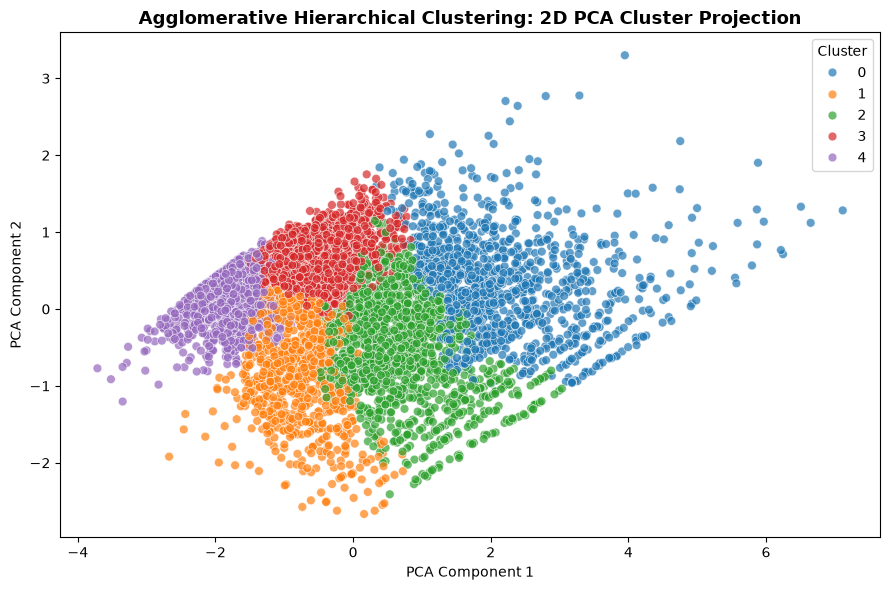

In [4]:
# 2D PCA Cluster Projection Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
rfm['PCA1'] = X_pca[:, 0]
rfm['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', alpha=0.7, s=40)
plt.title(f'{model_name}: 2D PCA Cluster Projection', fontsize=13, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()